In [48]:
# --------------------- Import Libraries ---------------------
import os
import copy
import sys
import yaml
import pickle
from pathlib import Path
from dataclasses import dataclass

import scanpy as sc
import anndata as ad


import numpy as np
import networkx as nx
import scipy.sparse as sp
from scipy.stats import pearsonr

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import umap
from matplotlib.lines import Line2D


In [49]:
##Opening the pickle file
with open("/nfs/users/nfs_d/dn10/lustre-127-tic/data/VQNiche/logs/xhs1000-39b_1p/standalone/VQNiche/batch=[2, 5, 10, 16]/spatial_n_neighs_8/wandb/offline-run-20250911_111648-zonhkp1j/results/epoch=8-train_pearson_1hop_nbr=0.88/predict_adata.pkl", "rb") as f:
    adata = pickle.load(f)

In [50]:
type(adata)

anndata._core.anndata.AnnData

In [51]:
adata.obs.head()

,cell_types,niche_types,adata_batch_ids
0,F2: Universal,Interstitial stroma,2
1,KC3,Interstitial stroma,2
2,F2: Universal,Interstitial stroma,2
3,T_vascular,Perivascular depeer,2
4,VE/Pericyte,Perivascular depeer,2


In [97]:
print('obsm keys:', adata.obsm.keys())
for k in adata.obsm.keys():
    print(k, adata.obsm[k].shape)

obsm keys: dict_keys(['spatial', 'H_latent', 'H_quantized', 'H_adj'])
spatial (44145, 2)
H_latent (44145, 200)
H_quantized (44145, 200)
H_adj (44145, 600)


In [61]:
adata.obs.columns

Index(['cell_types', 'niche_types', 'adata_batch_ids', 'code_index'], dtype='object')

In [57]:
print(adata.uns.keys())
for k in adata.uns.keys():
    print(k,type(adata.uns.keys()))

odict_keys(['X', 'X_nbr', 'edge_index', 'Indices', 'X_hat', 'X_hat_nbr', 'Logits', 'codebook_size', 'separate', 'num_heads'])
X <class 'odict_keys'>
X_nbr <class 'odict_keys'>
edge_index <class 'odict_keys'>
Indices <class 'odict_keys'>
X_hat <class 'odict_keys'>
X_hat_nbr <class 'odict_keys'>
Logits <class 'odict_keys'>
codebook_size <class 'odict_keys'>
separate <class 'odict_keys'>
num_heads <class 'odict_keys'>


In [63]:
indices = adata.uns['Indices']
print(type(indices))
print(indices[:5])
adata.obs['code_index'] = indices

<class 'torch.Tensor'>
tensor([2056, 3989, 1088, 4468, 1047])
0    2056
1    3989
2    1088
3    4468
4    1047
Name: code_index, dtype: int64


In [76]:
coords = adata.obsm['spatial']
x = coords[:, 0]
y = coords[:, 1]
codes = adata.obs['code_index'].astype(int)

In [72]:
print(adata.obsm['spatial'][:5])

[[3662.7605 2637.753 ]
 [3060.629  1816.9921]
 [1232.6648 2991.6477]
 [1286.35   3150.0386]
 [1283.2665 3139.8455]]


In [77]:
sample_batch_map = {
                    
                    'BK27_Day 14': 1,
                    'BK21_Lesional Baseline': 2,
                    'BK20_Lesional Baseline': 3,
                    'BK18_Non-lesional Baseline': 4,
                    'BK21_Day 3': 5,
                    'BK18_Week 12': 6,
                    'BK20_Day 14': 7,
                    'BK20_Non-lesional Baseline': 8,
                    'BK27_Non-lesional Baseline': 9,
                    'BK21_Day 14': 10,
                    'BK18_Lesional Baseline': 11,
                    'BK18_Day 3': 12,
                    'BK27_Day 3': 13,
                    'BK21_Non-lesional Baseline': 14,
                    'BK20_Week 12': 15,
                    'BK21_Week 12': 16,
                    'BK20_Day 3': 17,
                    'BK18_Day 14': 18,
                    'BK39_Lesional Baseline': 19,
                    'BK30_Non-lesional Baseline': 20,
                    'BK39_Non-lesional Baseline': 21,
                    'BK39_Week 12': 22,
                    'BK25_Day 3': 23,
                    'BK25_Day 14': 24,
                    'BK25_Non-lesional Baseline': 25,
                    'BK30_Day 3': 26,
                    'BK30_Day 14': 27,
                    'BK25_Lesional Baseline': 28,
                    'BK25_Week 12': 29,
                    'BK24_Lesional Baseline': 30,
                    'BK24_Day 14': 31,
                    'BK30_Lesional Baseline': 32,
                    'BK24_Non-lesional Baseline': 33,
                    'BK39_Day 14': 34,
                    'BK24_Day 3': 35,
                    'BK30_Week 12': 36,
                    'BK24_Week 12': 37,
                    'BK39_Day 3': 38
                    } 

In [13]:
#adata.obs['batch_name'] = adata.obs['adata_batch_ids'].map(sample_batch_map)


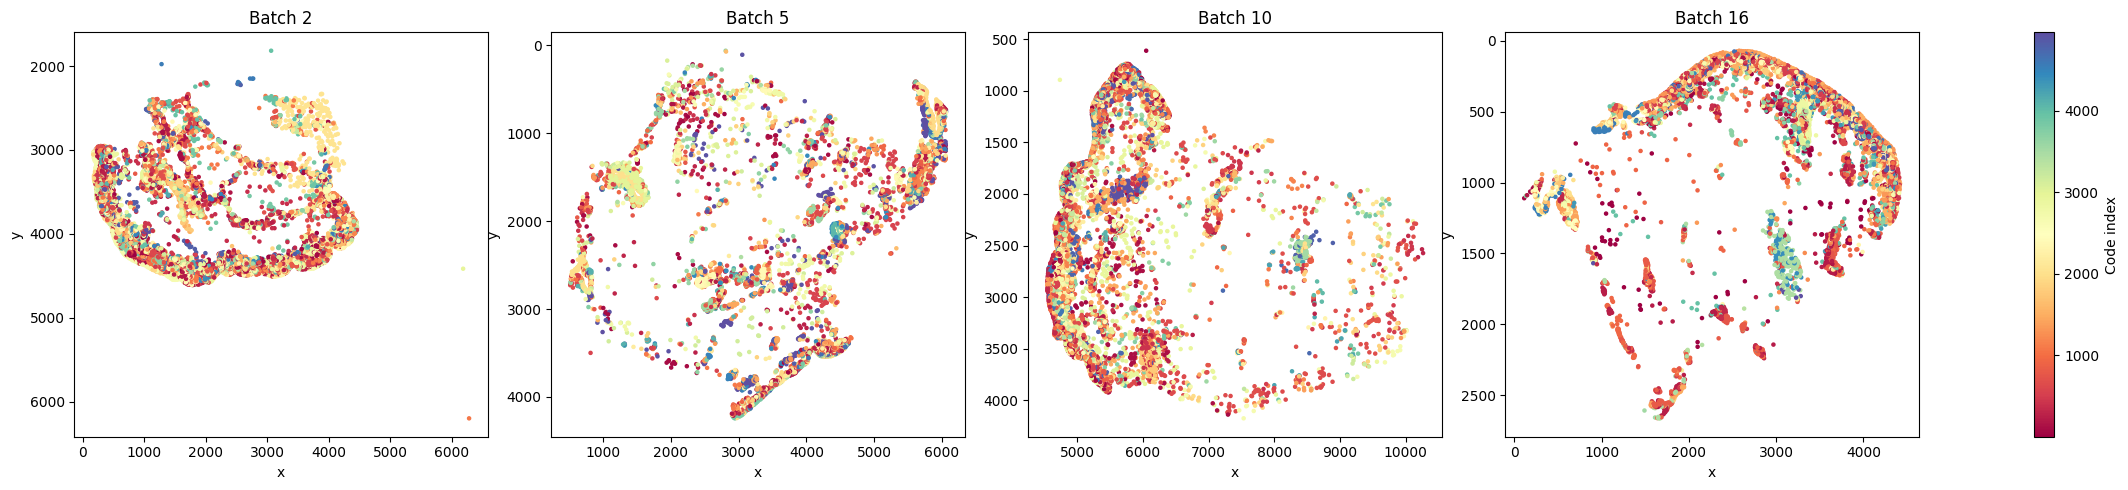

In [89]:
#Plotting tissues across batches(2,5,10,16)

batches = adata.obs['adata_batch_ids']
unique_batches = batches.dropna().unique()

fig, axes = plt.subplots(1, len(unique_batches), figsize=(6*len(unique_batches), 5))
if len(unique_batches) == 1:
    axes = [axes]

for ax, batch in zip(axes, unique_batches):
    idx = batches == batch
    sc = ax.scatter(
        x[idx],
        y[idx],
        c=codes[idx],              
        cmap='Spectral',           
        s=5
    )
    ax.invert_yaxis()
    ax.set_title(f'Batch {batch}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
fig.colorbar(sc, ax=axes, label='Code index')
plt.show()

In [90]:
print(adata.obs['adata_batch_ids'].unique())


[ 2  5 10 16]


In [117]:
embeddings = adata.obsm['H_quantized']

# labels
cell_types  = adata.obs['cell_types']
niche_types = adata.obs['niche_types']

In [118]:
#Fit UMAP

reducer = umap.UMAP()
embedding = reducer.fit_transform(embeddings)

In [119]:
print("shape of embedding:", embedding.shape)
print(len(cell_types))
#checking if any NaN embeddings
print(np.any(np.isnan(embedding)))

shape of embedding: (44145, 2)
44145
False


In [120]:
print(adata.obsm['H_quantized'].shape)
print(adata.obs.shape)

(44145, 200)
(44145, 4)


Batch 2 cells: 15566
Batch 5 cells: 9017
Batch 10 cells: 10500
Batch 16 cells: 9062


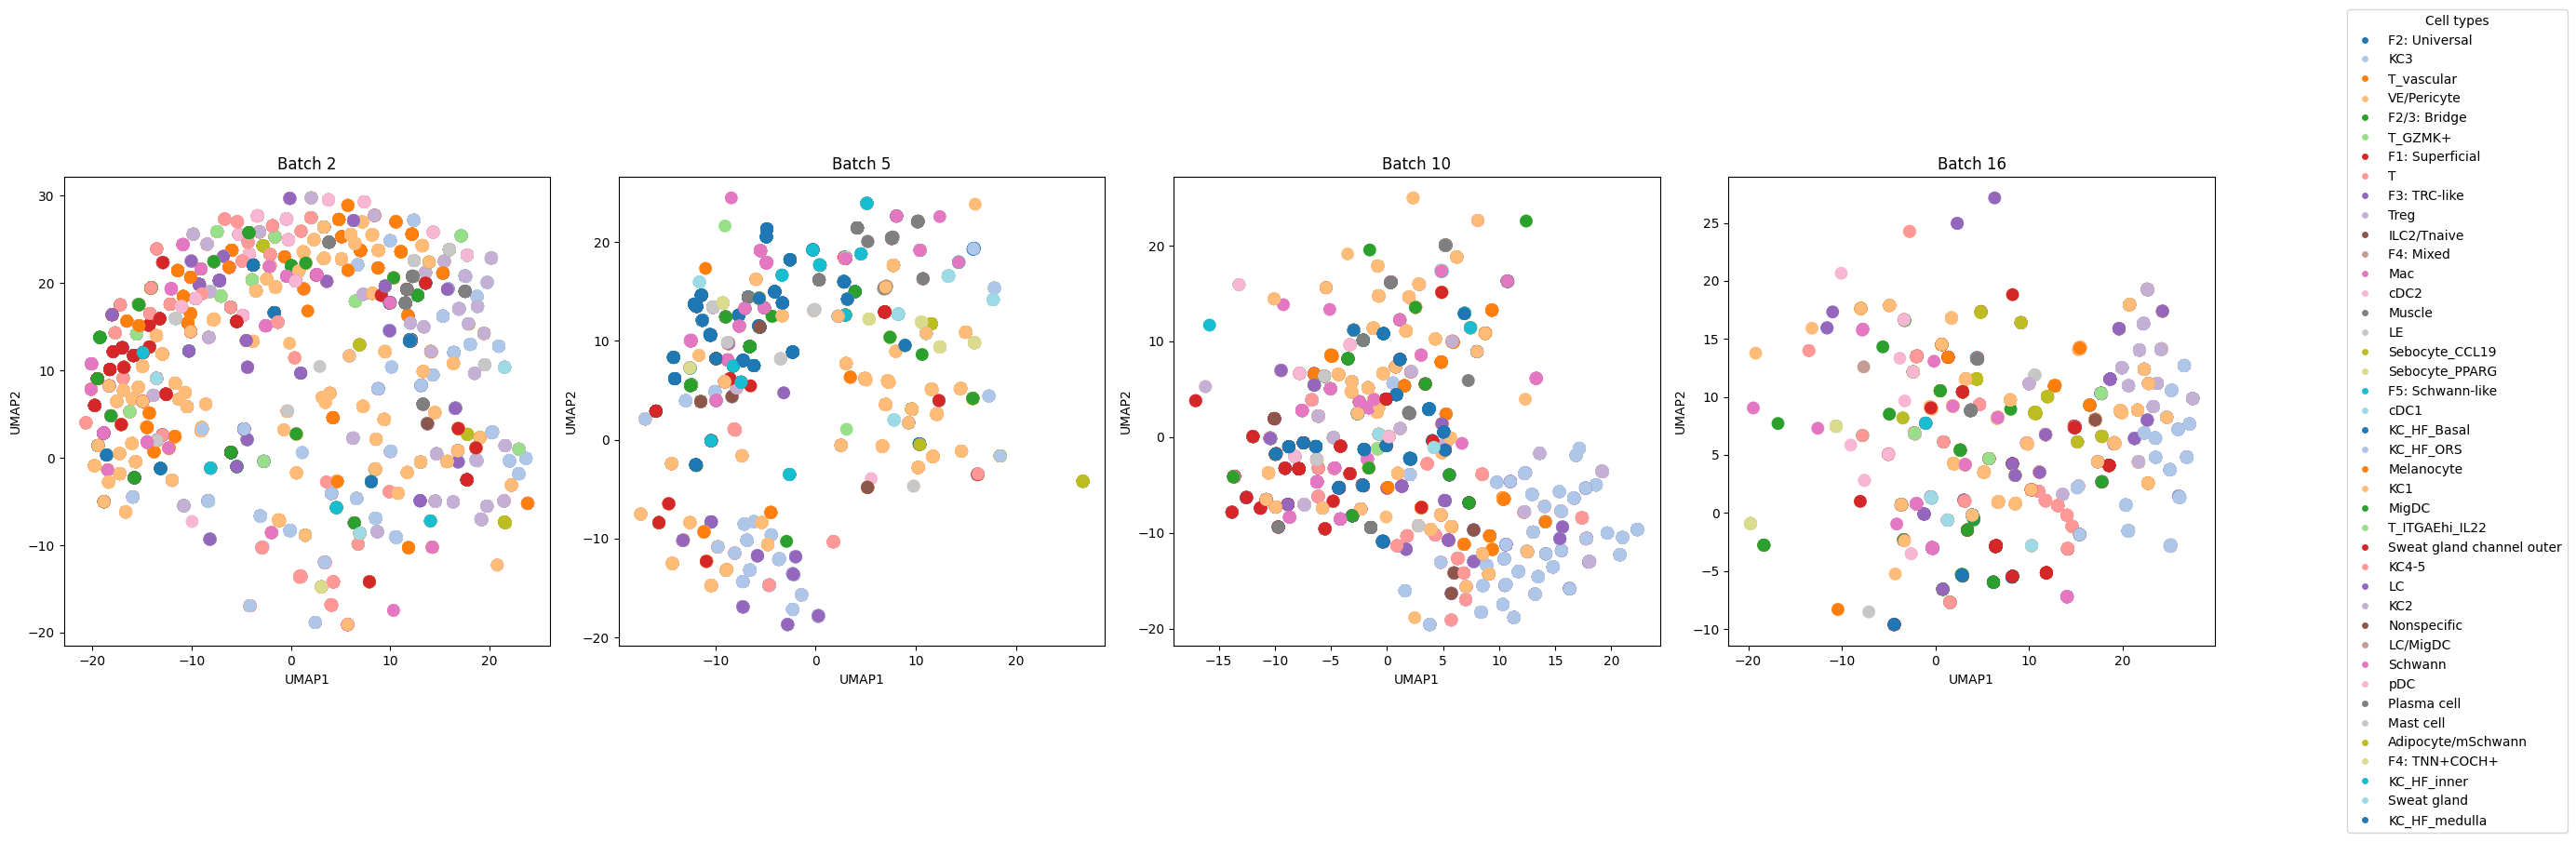

In [122]:
#UMAPs for H_quantized colored by cell types

batches = adata.obs['adata_batch_ids']

unique_batches = np.unique(batches.dropna())
unique_cell_types = cell_types.dropna().unique()
palette = sns.color_palette('tab20', n_colors=len(unique_cell_types))

# Create subplots side by side
fig, axes = plt.subplots(1, len(unique_batches), figsize=(6*len(unique_batches), 6))

if len(unique_batches) == 1:
    axes = [axes]

for ax, batch in zip(axes, unique_batches):
    idx = (batches == batch)
    sns.scatterplot(
        x=embedding[idx,0], y=embedding[idx,1],
        hue=cell_types[idx],  
        s=100, linewidth=0,
        palette=dict(zip(unique_cell_types, palette)),
        ax=ax,
        legend=False  
    )
    ax.set_title(f'Batch {batch}')
    ax.set_xlabel('UMAP1')
    ax.set_ylabel('UMAP2')
    print(f"Batch {batch} cells:", idx.sum())

# Build a global legend manually
handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=palette[i], markersize=6)
           for i in range(len(unique_cell_types))]
fig.legend(
    handles, unique_cell_types,
    bbox_to_anchor=(1.05, 0.5),
    loc='center left',
    markerscale=1,
    title='Cell types'
)

plt.tight_layout()
plt.show()
#print("Points actually drawn:", len(p.collections[0].get_offsets()))
assert embedding.shape[0] == len(cell_types), "Mismatch: not one point per cell"

In [126]:
#Checking celltype count for each batch to compare with the points plotted.
count = pd.crosstab(adata.obs['adata_batch_ids'], adata.obs['cell_types'])
total_per_batches = count.sum(axis=1)
print(total_per_batch)


adata_batch_ids
2     15566
5      9017
10    10500
16     9062
dtype: int64


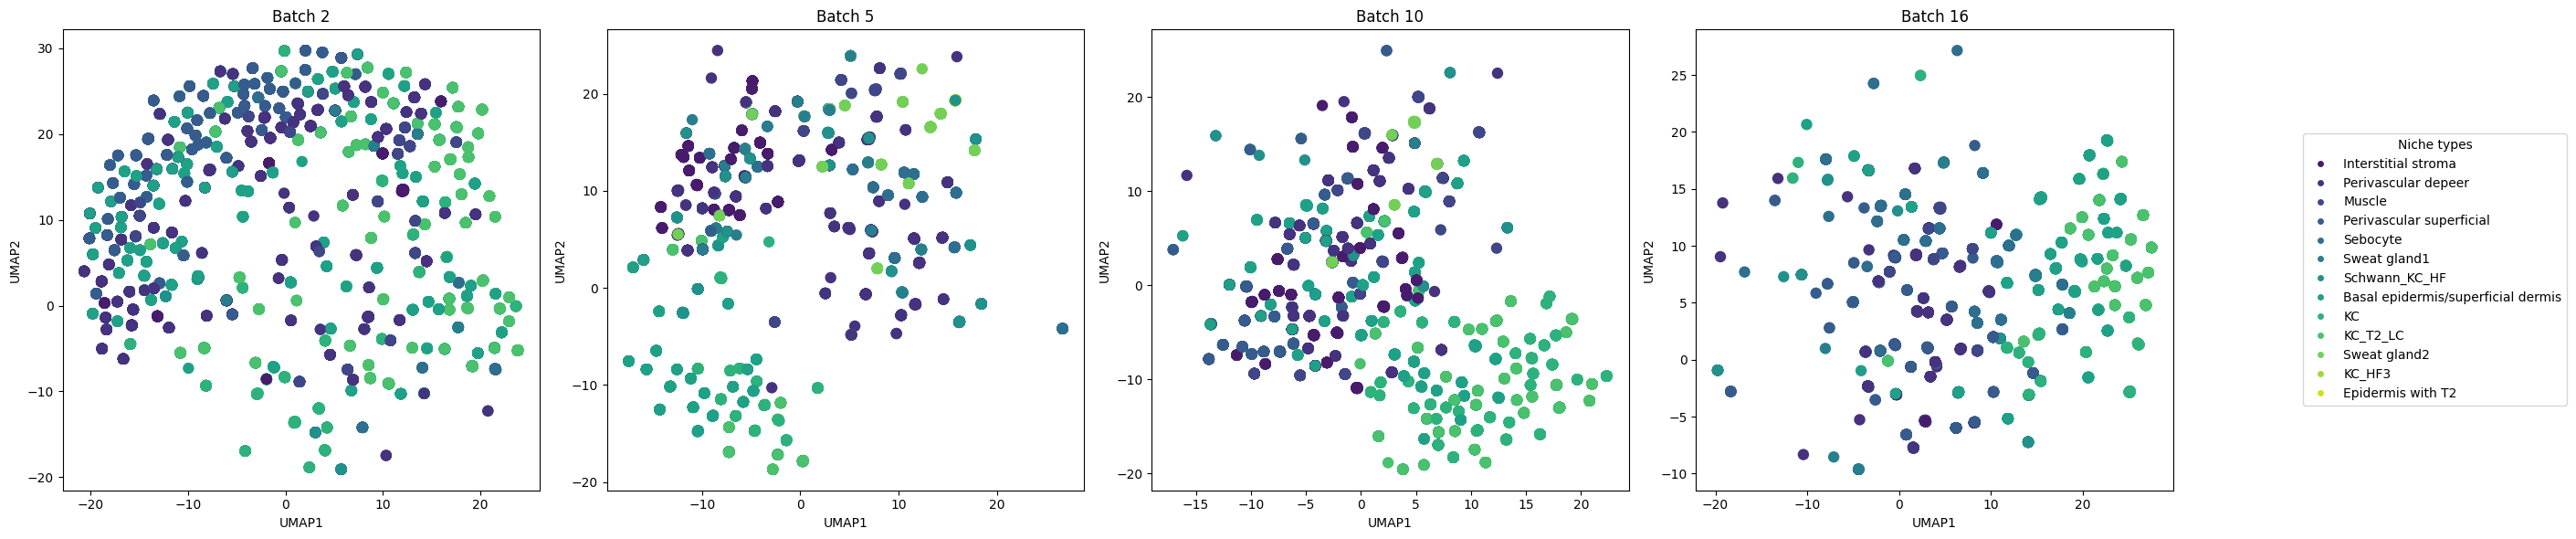

In [130]:
#UMAPs for H_quantized colored by niche_types

unique_niches = niche_types.dropna().unique()
palette = sns.color_palette('viridis', n_colors=len(unique_niches))  

fig, axes = plt.subplots(1, len(unique_batches), figsize=(6*len(unique_batches), 6))
if len(unique_batches) == 1:
    axes = [axes]

for ax, batch in zip(axes, unique_batches):
    idx = (batches == batch)
    sns.scatterplot(
        x=embedding[idx,0], y=embedding[idx,1],
        hue=niche_types[idx],
        s=80, linewidth=0,
        palette=dict(zip(unique_niches, palette)),
        ax=ax,
        legend=False
    )
    ax.set_title(f'Batch {batch}')
    ax.set_xlabel('UMAP1')
    ax.set_ylabel('UMAP2')
    #print(f"Batch {batch} niche:", idx.sum())

from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=palette[i], markersize=6)
           for i in range(len(unique_niches))]
fig.legend(
    handles, unique_niches,
    bbox_to_anchor=(1.05, 0.5),
    loc='center left',
    markerscale=1,
    title='Niche types'
)

plt.tight_layout()
plt.show()

